In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib
plt.rcParams.update({"text.usetex": True,
                     "axes.spines.right" : False,
                     "axes.spines.top" : False,
                     "font.size": 15,
                     "savefig.dpi": 400,
                     "savefig.bbox": 'tight',
                     'text.latex.preamble': r'\usepackage{amsfonts}'
                    }
                   )

from geomstats.geometry.euclidean import Euclidean
from geomstats.geometry.functions import SRVF, ProbabilityDistributions
from geomstats.information_geometry.normal import NormalDistributions
from geomstats.geometry.discrete_curves import DiscreteCurves
import geomstats.backend as gs

import fdasrsf as fs

INFO: Using numpy backend


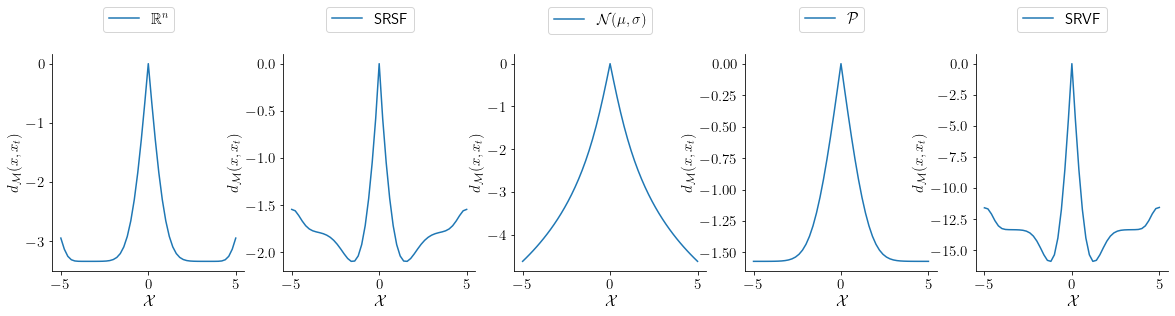

In [2]:
N_SAMPLES = 100
TARGET = [0,0.5]

lambda_ = np.linspace(-5,5,num=N_SAMPLES)

Rn = Euclidean(N_SAMPLES)
srvf = SRVF(lambda_)
normal = NormalDistributions()
pdist = ProbabilityDistributions(lambda_)

def gaussian(mu,sig):
    scale = 1/(np.sqrt(2*np.pi)*sig)
    return scale*np.exp(-np.power(lambda_ - mu, 2.) / (2 * np.power(sig, 2.)))

yt = gaussian(*TARGET)

dRn = lambda xi,yi : -float(Rn.metric.dist(yi, yt))
dSRSF = lambda xi,yi : -srvf.metric.dist(yi, yt)   
dNormal = lambda xi,yi : -normal.metric.dist(gs.array([xi,0.5]), gs.array(TARGET))
dPD = lambda xi,yi : -pdist.metric.dist(yi, yt)   

R2 = Euclidean(2)
curves = DiscreteCurves(R2)

def dSRVF(i,yi):
    yi_aug = gs.array([lambda_, yi]).T
    yt_aug = gs.array([lambda_, yt]).T
    return -curves.square_root_velocity_metric.dist(yi_aug, yt_aug)

test_x = np.linspace(-5, 5, 51)
fig, axs = plt.subplots(1,5,figsize=(4*5, 4))

ground_truth_Rn = [dRn(i, gaussian(i,TARGET[1])) for i in test_x]
axs[0].plot(test_x, ground_truth_Rn , label=r'$\mathbb{R}^n$')

ground_truth_srsf = [dSRSF(i, gaussian(i,TARGET[1])) for i in test_x]
axs[1].plot(test_x, ground_truth_srsf, label='SRSF')

ground_truth_normaldist = [dNormal(i, gaussian(i,TARGET[1])) for i in test_x]
axs[2].plot(test_x, ground_truth_normaldist, label=r'$\mathcal{N}(\mu, \sigma)$')

ground_truth_pdist = [dPD(i, gaussian(i,TARGET[1])) for i in test_x]
axs[3].plot(test_x, ground_truth_pdist, label=r'$\mathcal{P}$')

ground_truth_srvf = [dSRVF(i, gaussian(i,TARGET[1])) for i in test_x]
axs[4].plot(test_x, ground_truth_srvf, label=r'SRVF')

for ax in axs:
    ax.set_xlabel(r'$\mathcal{X}$')
    ax.set_ylabel(r'$d_{\mathcal{M}}(x, x_{t})$')
    ax.legend(ncol=2,loc='upper center',bbox_to_anchor=(0.45, 1.25))
plt.show()

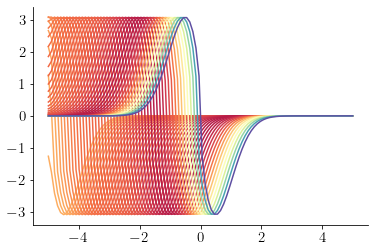

In [3]:
# inspect srvf's of all the functions
cmap = cm.get_cmap('Spectral')
norm = matplotlib.colors.Normalize(vmin=-2.2, vmax = 0)
fig, ax = plt.subplots()
for i in np.linspace(-5,0,50):
    y = gaussian(i, 0.5)
    q = srvf.metric.to_srvf(y)
    d = -srvf.metric.dist(y, yt)
    ax.plot(lambda_,q , color=cmap(norm(d)))
plt.show()

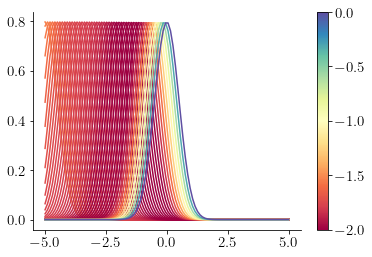

In [4]:
cmap = cm.get_cmap('Spectral')
norm = matplotlib.colors.Normalize(vmin=-2, vmax = 0)
fig, ax = plt.subplots()
for i in np.linspace(-5,0,50):
    y = gaussian(i, 0.5)
    d = -srvf.metric.dist(y, yt)
    ax.plot(lambda_,y , color=cmap(norm(d)))
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
plt.show()

In [5]:
def elastic_distance(xi, yi):
    curves = np.zeros((100, 2))
    curves[...,0] = yt
    curves[...,1] = yi
    obj = fs.fdawarp(curves, lambda_)
    obj.srsf_align(parallel=True)
    dp = fs.efda_distance_phase(obj.qn[...,0], obj.qn[...,1])
    da = fs.efda_distance(obj.qn[...,0], obj.qn[...,1])
    return da, dp

efda = np.asarray([elastic_distance(i, gaussian(i,TARGET[1])) for i in test_x])

Compute Karcher Mean of 2 function in SRSF space...
maximal number of iterations is reached
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean of 2 function in SRSF space...
maximal number of iterations is reached
Compute Karcher Mean of 2 function in SRSF space...
maximal number of iterations is reached
Compute Karcher Mean of 2 function in SRSF space...
maximal number of iterations is reached
Compute Karcher Mean of 2 function in SRSF space...
maximal number of iterations is reached
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean of 2 function in SRSF space...
Compute Karcher Mean

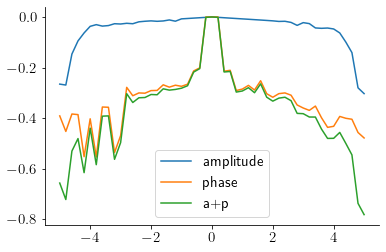

In [8]:
fig, ax = plt.subplots()
ax.plot(test_x, -efda[:,0], label = 'amplitude')
ax.plot(test_x, -efda[:,1], label = 'phase')
ax.plot(test_x, -efda.sum(axis=1), label = 'a+p')
ax.legend()
plt.show()